# Predikce rizika diabetu pomocí strojového učení
### Zpracování informací a znalostí
###### 2025/2026  
###### Jména: Petr Dvořák, Duc Anh Tran, Ondřej Hájek, Adam Jandušík, Quang Danh Nguyen   


In [35]:
## Vše co je naformátované v markdown, tak je základ semestrálky a musíme vypracovat jako minimum. 
## V sekcích pro kód dávám vysvětlivky co tam musíme dát. Všechny code komentáře se potom musí smazat!!

## 0 Načtení knihoven a datasetu

In [36]:
## import knihoven
import pandas as pd
import numpy as np
import pandas as pd
import re
from io import StringIO
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, silhouette_score
)
from sklearn.tree import plot_tree
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib
## načtení datasetu # dunno jestli to můžem takhle udělat takže prozatimně takhle
df = pd.read_csv('diabetes_dataset.csv')
print(df)


     Age  Gender Polyuria Polydipsia sudden weight loss weakness Polyphagia  \
0     40    Male       No        Yes                 No      Yes         No   
1     58    Male       No         No                 No      Yes         No   
2     41    Male      Yes         No                 No      Yes        Yes   
3     45    Male       No         No                Yes      Yes        Yes   
4     60    Male      Yes        Yes                Yes      Yes        Yes   
..   ...     ...      ...        ...                ...      ...        ...   
515   39  Female      Yes        Yes                Yes       No        Yes   
516   48  Female      Yes        Yes                Yes      Yes        Yes   
517   58  Female      Yes        Yes                Yes      Yes        Yes   
518   32  Female       No         No                 No      Yes         No   
519   42    Male       No         No                 No       No         No   

    Genital thrush visual blurring Itching Irritabi

## 1 Úvod

### 1.1 Byznysový význam
Diabetes patří mezi jednu z nejrozšířenějších civilizačních onemocnění, což představuje tedy významnou zátěž pro zdravotnictví a ekonomiku. Včasná identifikace rizikových pacientů by tedy umožnila preventivní zásahy, které by výrazně snížily náklady na léčbu komplikací spojených s pozdějšími stádii diabetu. Příkladem těchto komplikací může být např. kardiovaskulární onemocnění, selhání ledvin nebo poškození zraku.  

Z pohledu zdravotnictví může model strojového učení pomoci automatizovat předběžné vyhodnocení rizika diabetu na základě dostupných klinických a anamnestických údajů. To umožňuje lékařům soustředit se na pacienty s vyšším rizikem a zefektivnit diagnostický proces. Z pohledu byznysu by model mohl snížit náklady na pozdní léčbu, zvýšit kvalitu péče o pacienty a zlepšit alokaci zdravotnických zdrojů.

### 1.2  Odkaz na zdroj dat
Dataset je dostupný zde:  
https://www.openml.org/search?type=data&sort=version&status=any&order=asc&exact_name=diabetes_risk_prediction_dataset&id=46869

## 2  Přizpůsobení dat

### 2.1 Cílový atribut
* **Název**: _class (target)_
*  **Popis**: Říká jestli je pacient pozitivně nebo negativně diagnostikován s diabetem

### 2.2 Vybraná instance
* **Název**: _Polyuria_
* **Popis**: 

### 2.3 Atribut zájmu
* **Název**: _Polyuria_
* **Popis**:

### 2.4 Podmnožina zájmu
* **Název**: Pacienti s přítomností Polyuria  
* **Popis**: Podmnožina zájmu obsahuje všechny instance, u kterých je atribut Polyuria roven hodnotě „Yes“. Tato skupina pacientů byla vybrána, protože časté močení je jedním z typických příznaků diabetu a může indikovat zvýšené riziko onemocnění. Tato podmnožina je dále využita pro podrobnější analýzu vztahů mezi symptomy a cílovou proměnnou.

### 2.5  Matice nákladů

In [37]:
## Matice nákladů by mohla být dána uvedením nákladů na skutečně pozitivní výsledek (1), 
## skutečně negativní výsledek (1), falešně pozitivní výsledek (2) a falešně negativní výsledek (3). 
## Tím se vyjádří, že nejvyšší náklady vzniknou, když klasifikátor předpoví falešně negativní 
## diagnózu (pacient je predikován jako zdravý, ale ve skutečnosti má diabetes).
import pandas as pd
import numpy as np

TN_cost = 0
FP_cost = 2
FN_cost = 5
TP_cost = 1

cost_matrix = np.array([
    [TN_cost, FP_cost],
    [FN_cost, TP_cost]
])

cost_matrix_df = pd.DataFrame(
    cost_matrix,
    index=["Skutečně Negativní", "Skutečně Pozitivní"],
    columns=["Predikované Negativní", "Predikované Pozitivní"]
)

display(cost_matrix_df)

,Predikované Negativní,Predikované Pozitivní
Skutečně Negativní,0,2
Skutečně Pozitivní,5,1


## 3 Exploratorní analýza dat
Pro analýzu byly vybrány proměnné, které mají potenciální souvislost s přítomností diabetu nebo jsme je vybrali pro zajímavost.

* **class (target)** – cílová proměnná určující, zda pacient trpí diabetem  
* **Polyuria** – přítomnost nadměrného močení  
* **Polydipsia** – přítomnost nadměrné žízně  
* **Gender** – pohlaví pacienta  

### 3.1 Histogramy pro vybrané proměnné

#### 3.1.1 class (target)

Text(0, 0.5, 'Number of patients')

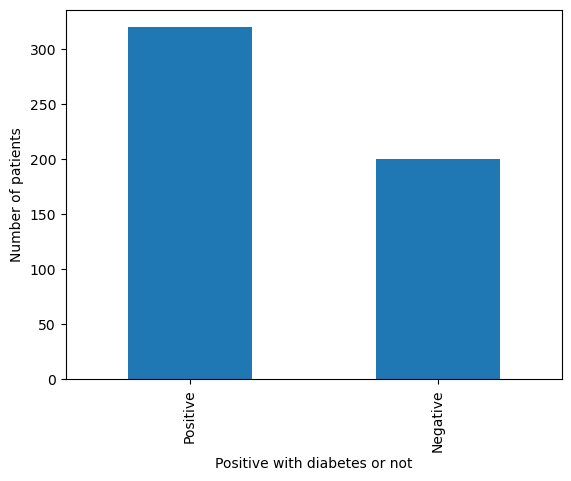

In [38]:
## Zobrazit histogram (nebo tabulku s četnostmi hodnot) pro cílovou proměnnou a pro 
## vybrané další proměnné.
df["class"].value_counts()

plt = df["class"].value_counts().plot(kind='bar')
plt.set_xlabel('Positive with diabetes or not')
plt.set_ylabel('Number of patients')

#### 3.1.2 Polyuria

Text(0, 0.5, 'Number of patients')

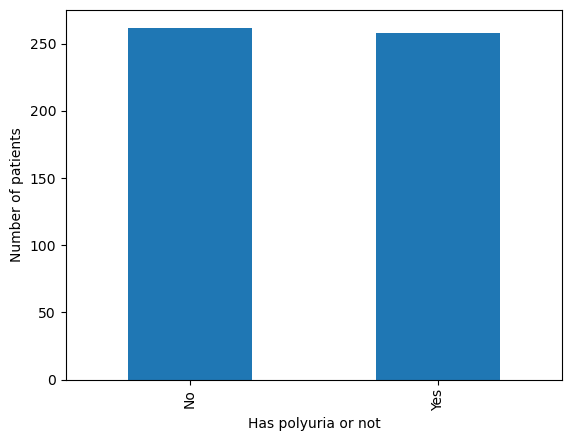

In [39]:
df["Polyuria"].value_counts()

plt = df["Polyuria"].value_counts().plot(kind='bar')
plt.set_xlabel('Has polyuria or not')
plt.set_ylabel('Number of patients')

#### 3.1.3 Polydispia

Text(0, 0.5, 'Number of patients')

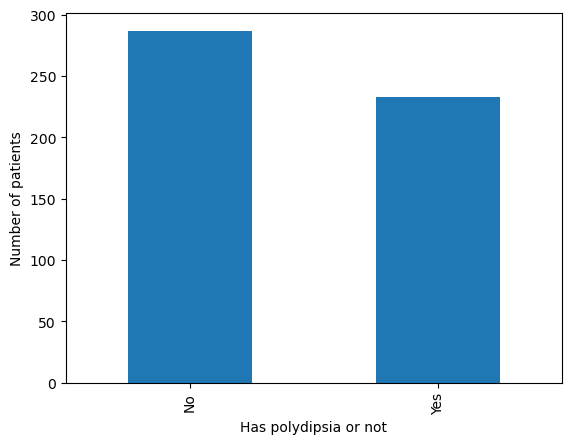

In [40]:
df["Polydipsia"].value_counts()

plt = df["Polydipsia"].value_counts().plot(kind='bar')
plt.set_xlabel('Has polydipsia or not')
plt.set_ylabel('Number of patients')

#### 3.1.3 Age

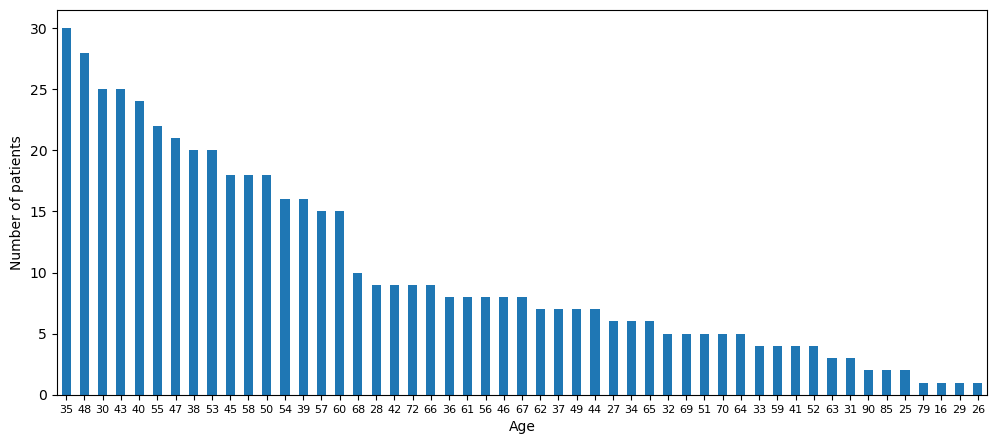

In [41]:
df["Age"].value_counts()

plt = df["Age"].value_counts().plot(kind='bar', figsize=(12, 5))
plt.set_xlabel('Age')
plt.set_ylabel('Number of patients')
plt.tick_params(axis='x', labelsize=8, rotation=0)

### 3.2 Korelační graf

#### 3.2.1 Polyuria vs class(target)

TypeError: 'Text' object is not callable

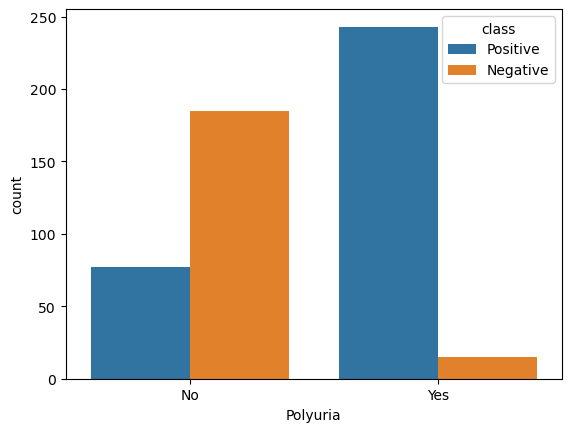

In [42]:
## Zobrazit graf rozptylu (korelační graf) znázorňující vztah mezi vybranými prediktory a 
## cílovou proměnnou.

##VERZE A (přehlednější)
import seaborn as sns

sns.countplot(x="Polyuria", hue="class", data=df)

plt.title("Polyuria vs Diabetes")
plt.show()

In [ ]:
## Zobrazit graf rozptylu (korelační graf) znázorňující vztah mezi vybranými prediktory a 
## cílovou proměnnou.

## VERZE B (podle zadání, ale méně přehledná)
x = df_encoded["Polyuria"] + np.random.normal(0, 0.05, len(df_encoded))
y = df_encoded["class"] + np.random.normal(0, 0.05, len(df_encoded))

plt.scatter(x, y, alpha=0.3, s=15, edgecolors='k', linewidths=0.3)

plt.xlabel("Polyuria (0 = No, 1 = Yes)")
plt.ylabel("Diabetes (0 = No, 1 = Yes)")
plt.title("Correlation between Polyuria and Diabetes (with density view)")

plt.show()

#### 3.2.2 Polydipsia vs class(target)

In [ ]:
sns.countplot(x="Polydipsia", hue="class", data=df)

plt.title("Polydipsia vs Diabetes")
plt.show()

#### 3.2.3 Age vs class(target)

In [ ]:
plt.figure(figsize=(12, 5))

plt.scatter(df_encoded["Age"], df_encoded["class"], alpha=0.5, s=20)

plt.xlabel("Age")
plt.ylabel("Diabetes (0 = No, 1 = Yes)")
plt.title("Correlation between Age and Diabetes")

plt.show()

In [ ]:
## Bude jen krátký popis podle našich grafů.

### 3.3 Interpretace výsledků

Na základě histogramů cílové proměnné _class(target)_ bylo zjištěno, že dataset je nevyvážený, přičemž počet pacientů s diabetem značně převažuje počet pacientů s negativní diagnózou. Tato skutečnost může ovlivnit výběr vhodné metriky pro hodnocení modelu, proto může být vhodné využít F1-míru. Analýza vybraných proměnných ukázala, že některé atributy, zejména _Polyuria_ a _Polydipsia_, vykazují silnější vztah k výskytu diabetu. U těchto proměnných je patrný rozdíl v rozdělení mezi pozitivní a negativní třídou. Naopak proměnná _Age_ vykazuje pouze mírnou souvislost s cílovou proměnnou, což naznačuje, že tato proměnná není sama dostatečně spolehlivým prediktorem. 


## 4 Předzpracování dat

### 4.1 Předzpracování dat pro strojové učení s učitelem

In [ ]:
## Petr, Adam, Tom
## a) Rozdělit data na trénovací a testovací
## b) Pokud jsou data nevyvážená tak trénovací soubor buď zvětšit nebo zmenšit pomocí převzorkování
## c) Feature selection - odstranění některých atributů
## Operace z předzpracování nepoužívá informace z testovací sady!!!

## KÓD
df["class"] = df["class"].map({"Positive": 1, "Negative": 0})

dataFrameCommon = df.drop(["Age", "Gender", "class"], axis=1)
featuresCommon = dataFrameCommon.columns

for x in featuresCommon:
    df[x] = df[x].map({'Yes':1, 'No':0})

df["Gender"] = df["Gender"].map({'Male':1,'Female':0})

#Splitting data - modify test size at your leasure, just tell everyone you did it
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2,random_state=42)


## Oversampling cuz it sounds better
negative = train[train["class"] == 0]
positive = train[train["class"] == 1]

negative_overs = negative.sample(
    n=len(positive),
    replace=True,
    random_state=42
)

train_balanced = pd.concat([positive, negative_overs])

### 4.2 Předzpracování dat pro modely bez učitele

In [ ]:
## Ondra, David
## a) Odstranit řádky, které nejsou v podskupině
## b) Normalizace třídy věku

## KÓD
df_unsup = pd.read_csv("diabetes_dataset.csv")

# převod kategorií na čísla
df_unsup["class"] = df_unsup["class"].map({"Positive": 1, "Negative": 0})

# Yes/No → 1/0
symptom_cols = [col for col in df_unsup.columns if col not in ["Age", "Gender", "class"]]

for col in symptom_cols:
    df_unsup[col] = df_unsup[col].map({"Yes": 1, "No": 0})

# Gender → číslo
df_unsup["Gender"] = df_unsup["Gender"].map({"Male": 1, "Female": 0})

# výběr podmnožiny
df_unsup = df_unsup[df_unsup["Polydipsia"] == 1].copy()

# ODSTRANĚNÍ TARGETU ... učení bez učitele
X_unsup = df_unsup.drop(columns=["class"])

# škálování dat (důležité pro clustering)
scaler = StandardScaler()
X_unsup_scaled = scaler.fit_transform(X_unsup)

## 5 Modelování dat

In [ ]:
## Popsat použité parametry

### 5.1 Klasifikační modely

In [ ]:
## a) Trénovat model na trénovacích datech a vyhodnotit ho na testovacích datech
## b) Vyzkoušet různé kombinace metaparametrů (např. hloubka stromu, počet stromů v lese atd.) 

#### 5.1.1 Rozhodovací stromy

In [ ]:
## KÓD
x_train = train_balanced.drop(columns=["class"])
y_train = train_balanced[["class"]]
x_test = test.drop(columns=['class'])
y_test = test[['class']]

decisionTreeClasiffier = DecisionTreeClassifier(random_state=42, max_depth=8)
decisionTreeClasiffier.fit(x_train,y_train)

pred = decisionTreeClasiffier.predict(x_test)
#print(pred)


plt.figure(figsize=(30,30))

dtcClasses=["DiseasePositive","DiseaseNegative"]
x=plot_tree(decisionTreeClasiffier, feature_names=decisionTreeClasiffier.feature_names_in_, class_names=dtcClasses)

## Dvakrát klikněte na strom pro zvětšení

#### 5.1.1 Náhodné lesy

In [ ]:
## KÓD

# Random Forest budeme trénovat na stejných datech jako rozhodovací strom, aby šlo výsledky porovnat.
# Chceme 100 stromů
pocet_stromu = 100
hloubka_stromu = 4
randomForestClassifier = RandomForestClassifier(
    n_estimators=pocet_stromu,
    max_depth=hloubka_stromu,
    random_state=42
)

# trénování
randomForestClassifier.fit(x_train, y_train.values.ravel()) # chceme 1D pole z 2D

# predikce
pred = randomForestClassifier.predict(x_test)


In [ ]:
# příklad: první strom ze 100 stromů v Random Forest
first_tree = randomForestClassifier.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(
    first_tree,
    feature_names=x_train.columns,
    class_names=["Negative", "Positive"],
    filled=True,
    max_depth=4
)
plt.title("Strom č. 0")
plt.show()

In [ ]:
#Graf: jak moc každá featura hraje roli v predikci

#random forest umi výpočítat důležitost pro každou featuru z naších 100 stromů

# hodnota důležitosti např. [0.5, 0.32, 0.25, atd...]
importances = randomForestClassifier.feature_importances_
# nazev těch featur
features = x_train.columns

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Důležitost atributů v Random Forest")
plt.xlabel("Importance")
plt.ylabel("Atribut")
plt.show()

#interpretace výsledků (viz grafu)
  # vidíme, že polydipsia má nejvyšší hodnotu 
    #(např. pokud člověk chodí často na záchod, je to vysoká pravděpodobnost, že má diabetu)

### 5.2 Shlukovací modely

In [ ]:
## a) Vyzkoušet různá nastavení shlukování
## b) Vyzkoušet různá nastavení metaparametrů (např. pošet shluků pro k-means)
## c) Vybrat nejvhodnější hodnotu

#### 5.2.1 Ploché shlukování

In [ ]:
## KÓD
# různá nastavení shlukování
for k in [4, 5, 6]:
    print(f"K = {k}")
    
    kmeans_model = KMeans(n_clusters=k, random_state=42)
    labels_kmeans = kmeans_model.fit_predict(X_unsup_scaled)

    # přidáme sloupec "cluster" (viz tab dole)
    df_kmeans_temp = df_unsup.copy()
    df_kmeans_temp["cluster_kmeans"] = labels_kmeans
    
    print("Počet lidí ve shlucích:")
    print(df_kmeans_temp["cluster_kmeans"].value_counts().sort_index())
    
    print("Průměry:")
    display(df_kmeans_temp.groupby("cluster_kmeans").mean(numeric_only=True))

Byly vyzkoušeny různé hodnoty počtu shluků (k = 4,5,6). 
Na základě porovnání velikosti shluků a průměrných hodnot atributů bylo jako nejvhodnější zvoleno k = 6.

In [ ]:
# PCA na 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_unsup_scaled)


# finální model (k = 6)
kmeans_model = KMeans(n_clusters=6, random_state=42)
labels_kmeans = kmeans_model.fit_predict(X_unsup_scaled)

# graf
plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans)
plt.title("Ploché shlukování (k = 6)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

Každý bod = každý pacient.  
Barva = cluster (K=means) 

#### 5.2.2 Hierarchické shlukování

In [ ]:
## KÓD
# stejný počet shluků (k=6) jako u plochého shlukování, aby bylo možné výsledky porovnat
agg_model = AgglomerativeClustering(n_clusters=6)
labels_agg = agg_model.fit_predict(X_unsup_scaled)

df_agg_temp = df_unsup.copy()
df_agg_temp["cluster_agg"] = labels_agg

print("Počet lidí ve shlucích:")
print(df_agg_temp["cluster_agg"].value_counts().sort_index())

print("Průměry:")
display(df_agg_temp.groupby("cluster_agg").mean(numeric_only=True))

In [ ]:
# model
agg_model = AgglomerativeClustering(n_clusters=6)
labels_agg = agg_model.fit_predict(X_unsup_scaled)

# graf
plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_agg)
plt.title("Hierarchické shlukování (k = 6)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

## 6 Evaluace

### 6.1 Klasifikační model

In [ ]:
## a) Vybrat nejvhodnější metriku pro náš dataset (správnost, Fmíra??, musíme ještě vymyslet)
## b) Porovnat výkonnostní metriky pro oba typy algoritmů (stromy a lesy) a vybrat ten lepší
## c) Dosadit výsledky našich modelů do matice nákladů a vybrat ten nejlepší z hlediska nákladů 
##    (chceme co nejnižší náklady)
## d) Vyzkoušet různé prahy pravděpodobnosti. Jaký práh dává nejnižší náklady?

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(x_train, y_train.squeeze()) # the squeeze is unnecesary here
    y_pred = model.predict(x_test)

    print(name)
    print(classification_report(y_test, y_pred))


    confusMatrix = confusion_matrix(y_test, y_pred)
    print(confusMatrix)
    total_cost = np.sum(confusMatrix * cost_matrix)
    print(f"Celkové náklady: {total_cost}")

    y_proba = model.predict_proba(x_test)[:, 1]
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_cost = float("inf")
    best_t = 0
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        confusMatrixThreash = confusion_matrix(y_test, y_pred)
        cost = np.sum(confusMatrixThreash*cost_matrix)

        if cost < best_cost:
            best_cost = cost
            best_t = t

    print("Best threshold:", best_t)
    print("Lowest cost:", best_cost)

In [ ]:
## e) Kvantifikujte vliv jednotlivých kroků předzpracování (například změny měřítka). 
##    Jak by se změnil prediktivní výkon, kdybyste tento krok neprovedli (nepovinné).

#x_train = train_balanced.drop(columns=["class"])
#y_train = train_balanced[["class"]]
x_train_raw = train.drop(columns=["class"])
y_train_raw = train[["class"]]
#x_test = test.drop(columns=['class'])
#y_test = test[['class']]

# without additional preprocess
model1 = RandomForestClassifier(random_state=42)
model1.fit(x_train_raw, y_train_raw.squeeze())
pred1 = model1.predict(x_test)

# with additional preprocess
model2 = RandomForestClassifier(random_state=42)
model2.fit(x_train, y_train.squeeze())
pred2 = model2.predict(x_test)

# compare F1
f1_raw = f1_score(y_test, pred1)
f1 = f1_score(y_test, pred2)

print(f"Bez overfittingu: {f1_raw}")
print(f"S overfittingem: {f1}")  

### 6.2 Shlukování

In [ ]:
## a) Zdůvodnit zvolené k (počet shluků) pomocí grafu loketní křivky WCSS nebo Silhouette score

# WCSS metoda
wcss = []
# pro každou hodnotu pro k, vypočítáme wsss
for k in range(2, 10):
    kmeans_eval = KMeans(n_clusters=k, random_state=42)
    kmeans_eval.fit(X_unsup_scaled)
    wcss.append(kmeans_eval.inertia_)

plt.plot(range(2, 10), wcss, marker='o')
plt.xlabel("Počet shluků (k)")
plt.ylabel("WCSS")
plt.title("Elbow/WCSS metoda")
plt.show()

k_v_grafu = 2
print("Spočítáme rozdíly")
for i in range(len(wcss)-1):
    print(f"přechod: {k_v_grafu}->{k_v_grafu+1} ... {wcss[i]:.2f} - {wcss[i+1]:.2f} = {(wcss[i] - wcss[i+1]):.2f}")
    k_v_grafu +=1

Analýza poklesu hodnot WCSS ukázala, že výrazné zlepšení modelu probíhá do hodnoty k = 6. Po této hodnotě dochází k velkému zpomalení poklesu WCSS, proto optimální počet shluků je 6

In [ ]:
## b) Vyhodnocení kvality shlukování pomocí některé z interních nebo externích metrik
# vypočítat silhouette score pro optimální k = 6
# KMeans/ ploché shlukování
kmeans_model = KMeans(n_clusters=6, random_state=42)
labels_kmeans = kmeans_model.fit_predict(X_unsup_scaled)
score_kmeans = silhouette_score(X_unsup_scaled, labels_kmeans)

print(f"Silhouette score (KMeans, k=6): {score_kmeans:.3f}")

# Hierarchické shlukování
agg_model = AgglomerativeClustering(n_clusters=6)
labels_agg = agg_model.fit_predict(X_unsup_scaled)
score_agg = silhouette_score(X_unsup_scaled, labels_agg)

print(f"Silhouette score (Hierarchické, k=6): {score_agg:.3f}")

Silhouette score bylo vypočteno pro oba algoritmy při k = 6.  
Pro ploché shlukování (KMeans) vyšla hodnota přibližně 0.13 a pro hierarchické shlukování vyšla hodnota přibližně 0.11.  

Vyšší hodnota u silhouette score znamená, že algoritmus vytvořil lépe shluky.  
U našeho případu silhouette score pro oba algoritmy jsou nízké, 0.13 a 0.11, což znamená, že struktura dat není dobře a silně shluková.
Shluky se částečně 

## 7 Interpretace dat

### 7.1 Klasifikace

In [ ]:
## a) Určit nejdůležitější proměnné v modelu a vysvětlit jak model stromu dospěl ke svému 
##    závěru (které větve a uzly stromu byly aktivovány?)
## b) Použít oba modely (stromy i lesy) ke klasifikaci vybrané instance a určit spolehlivost 
##    (pravděpodobnost) predikce
## c) Pokud byste změnili hodnotu atributu zájmu, jak by se změnila klasifikace instance? 
##    V programu scikit-learn můžete použít graf ICE (volitelně)
## d) Použít LIME, SHAPLEY nebo Anchors k vysvětlení klasifikace instance (volitelně)

# a) Nejdůležitější atributy podle rozhodovacího stromu a náhodného lesu
tree_importance = pd.Series(decisionTreeClasiffier.feature_importances_, index=x_train.columns).sort_values(ascending=False)
forest_importance = pd.Series(randomForestClassifier.feature_importances_, index=x_train.columns).sort_values(ascending=False)

print("Top 5 atributů - rozhodovací strom:")
print(tree_importance.head(5))
print("\nTop 5 atributů - náhodný les:")
print(forest_importance.head(5))

# b) Klasifikace vybrané instance oběma modely
instance = x_test.iloc[[0]]
print("\nVybraná instance:")
print(instance)

tree_pred = decisionTreeClasiffier.predict(instance)[0]
tree_prob = decisionTreeClasiffier.predict_proba(instance)[0][1]

forest_pred = randomForestClassifier.predict(instance)[0]
forest_prob = randomForestClassifier.predict_proba(instance)[0][1]

print(f"\nStrom - predikce: {tree_pred}, pravděpodobnost pozitivní: {tree_prob:.2f}")
print(f"Les   - predikce: {forest_pred}, pravděpodobnost pozitivní: {forest_prob:.2f}")

# c) Změna atributu zájmu (Polydipsia) a porovnání výsledku
instance_changed = instance.copy()
instance_changed["Polydipsia"] = 1 - instance_changed["Polydipsia"].values[0]

print(f"\nPo změně Polydipsia:")
print(f"Strom - pravděpodobnost pozitivní: {decisionTreeClasiffier.predict_proba(instance_changed)[0][1]:.2f}")
print(f"Les   - pravděpodobnost pozitivní: {randomForestClassifier.predict_proba(instance_changed)[0][1]:.2f}")

### 7.2 Shlukování

In [ ]:
## a) Interpretovat konečné shluky na základě jejich centroidů a počtu instancí v každém shluku
## b) Pomocí modelu dosadit vybranou instanci do shluku a zkontrolovat přiřazený shluk
## c) Shoduje se hodnota cílové třídy v datech s nejčastější třídou v přiřazeném shluku (nepovinné)?
# a) Finální shlukování (k=2) - počet instancí a centroidy
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_unsup_scaled)

df_final = df_unsup.copy()
df_final["cluster"] = labels

print("Počet instancí v jednotlivých shlucích:")
print(df_final["cluster"].value_counts().sort_index())

print("\nCentroidy (průměry atributů v každém shluku):")
display(df_final.groupby("cluster").mean(numeric_only=True))

# b) Zařazení vybrané instance do shluku
instance_idx = 0
instance = X_unsup_scaled[instance_idx:instance_idx+1]
cluster_id = kmeans.predict(instance)[0]

print(f"\nVybraná instance byla přiřazena do shluku: {cluster_id}")

# c) Porovnání skutečné třídy instance s nejčastější třídou ve shluku
skutecna_trida = df_unsup.iloc[instance_idx]["class"]
nejcastejsi_trida = df_final[df_final["cluster"] == cluster_id]["class"].mode()[0]

print(f"Skutečná třída instance: {skutecna_trida}")
print(f"Nejčastější třída ve shluku {cluster_id}: {nejcastejsi_trida}")
print("Shoduje se:", skutecna_trida == nejcastejsi_trida)


## 8 Závěr

In [ ]:
## Závěr by měl být jen textový
## Shrnout výsledky a odpovědět na následující otázky:
## 1. Který výsledek strojového učení má nejvyšší hodnotu a je nejzajímavější? 
## 2. Jaké nastavení poskytlo nejlepší výsledek? 
## 3. Které atributy jsou nejdůležitější?


# Závěrečný kontrolní seznam 

* Jsou všechny kroky předzpracování zdůvodněné?
* Vyzkoušeli jste různé hodnoty metaparametrů modelovacích algoritmů?
* Jsou výsledky opakovatelné? Pokud máte k dispozici stejná data, popisuje zpráva všechny kroky dostatečně podrobně, abyste získali stejné výsledky?
* Byly zvoleny správné hodnotící metriky? Jsou výsledky správně interpretovány?
* Jsou všechny důležité kroky vysvětleny a zdůvodněny?
* Jaká je kvalita textu? Je jazyk jasný a stručný?

# SMAZAT TUTO BUŇKU NA KONCI!!!
